In [3]:
import pandas as pd
bitcoin = pd.read_csv("fear_greed_index.csv")
historical = pd.read_csv("historical_data.csv")

In [5]:
print(bitcoin.shape)
print(historical.shape)

(2644, 4)
(211224, 16)


In [6]:
print(bitcoin.isnull().sum())
print(historical.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [7]:
print(bitcoin.duplicated().sum())
print(historical.duplicated().sum())

0
0


In [17]:
print(bitcoin.dtypes)
print(historical.dtypes)

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object
Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST               object
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp           datetime64[ns]
dtype: object


In [20]:
historical['date'] = historical['Timestamp'].dt.date
bitcoin['date'] = pd.to_datetime(bitcoin['date'], errors='coerce').dt.date

In [24]:
df = pd.merge(historical,bitcoin[['date', 'classification']],on='date',how='left')
print(df)

                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [29]:
daily_pnl = df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
print(daily_pnl)

                                       Account        date    Closed PnL
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1970-01-01  1.600230e+06
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  1970-01-01  4.788532e+04
2   0x271b280974205ca63b716753467d5a371de622ab  1970-01-01 -7.043619e+04
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1970-01-01  1.324648e+05
4   0x2c229d22b100a7beb69122eed721cee9b24011dd  1970-01-01  1.686580e+05
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  1970-01-01 -3.120360e+04
6   0x39cef799f8b69da1995852eea189df24eb5cae3c  1970-01-01  1.445692e+04
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  1970-01-01  5.349625e+04
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641  1970-01-01  1.995056e+05
9   0x430f09841d65beb3f27765503d0f850b8bce7713  1970-01-01  4.165419e+05
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85  1970-01-01  1.033437e+05
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  1970-01-01  6.777471e+05
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760  197

In [32]:
df['win'] = df['Closed PnL'] > 0
print(df['win'])
win_rate = df.groupby('Account')['win'].mean()
print(win_rate)

0         False
1         False
2         False
3         False
4         False
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Name: win, Length: 211224, dtype: bool
Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4

In [34]:
trades_per_day = df.groupby('date').size()
print(trades_per_day)

date
1970-01-01    211224
dtype: int64


In [36]:
long_short = df['Side'].value_counts(normalize=True)
print(long_short)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [41]:
print(historical.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')


In [43]:
df['approx_leverage'] = df['Size USD'] / (df['Start Position'].abs() + 1)
print(df['approx_leverage'])

0         7872.160000
1            0.129293
2            1.146595
3            0.995191
4            0.054049
             ...     
211219       0.055753
211220       0.326378
211221       0.092468
211222       0.858265
211223       1.099921
Name: approx_leverage, Length: 211224, dtype: float64


In [56]:
historical['Timestamp IST'] = pd.to_datetime(historical['Timestamp IST'],errors='coerce')
historical['date'] = historical['Timestamp IST'].dt.floor('D')

In [59]:
bitcoin['date'] = pd.to_datetime(bitcoin['date'],errors='coerce').dt.floor('D')

In [60]:
df = pd.merge(historical,bitcoin[['date', 'classification']],on='date',how='left')

In [63]:
print(df[['date','classification']].head(10))
print(df['classification'].value_counts())

        date classification
0 2024-02-12          Greed
1 2024-02-12          Greed
2 2024-02-12          Greed
3 2024-02-12          Greed
4 2024-02-12          Greed
5 2024-02-12          Greed
6 2024-02-12          Greed
7 2024-02-12          Greed
8 2024-02-12          Greed
9 2024-02-12          Greed
classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


In [65]:
df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,1.891632
Extreme Greed,205.816345
Fear,128.287950
Greed,53.988003
Neutral,27.088803


<Axes: xlabel='classification', ylabel='Closed PnL'>

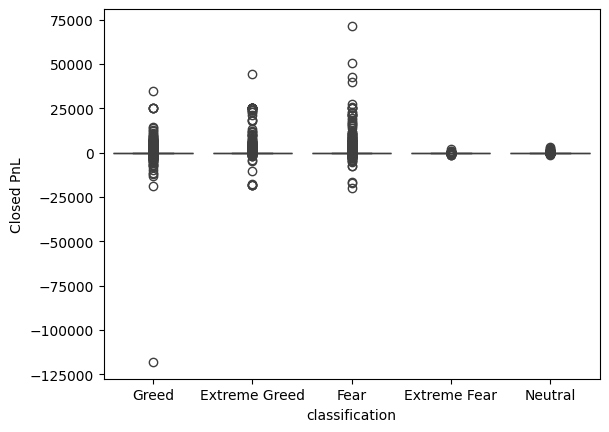

In [67]:
import seaborn as sns
sns.boxplot(x='classification', y='Closed PnL', data=df)

In [68]:
df.groupby('classification').size()

,0
classification,
Extreme Fear,2326
Extreme Greed,5621
Fear,13869
Greed,11292
Neutral,2756


In [72]:
df['approx_leverage'] = df['Size USD'] / (df['Start Position'].abs() + 1)
df.groupby('classification')['approx_leverage'].mean()

,approx_leverage
classification,
Extreme Fear,630.082461
Extreme Greed,670.577406
Fear,552.549302
Greed,1067.027588
Neutral,1624.620009


In [75]:
pd.crosstab(df['classification'], df['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898


In [77]:
df['approx_leverage'] = df['Size USD'] / (df['Start Position'].abs() + 1)
df['lev_group'] = df['approx_leverage'].apply(lambda x: 'High' if x > 5 else 'Low')
print(df['lev_group'])

0         High
1          Low
2          Low
3          Low
4          Low
          ... 
211219     Low
211220     Low
211221     Low
211222     Low
211223     Low
Name: lev_group, Length: 211224, dtype: object


In [81]:
trade_counts = df['Account'].value_counts()
df['freq_group'] = df['Account'].map(lambda x: 'High' if trade_counts[x] > 50 else 'Low')
print(df['freq_group'])

0         High
1         High
2         High
3         High
4         High
          ... 
211219    High
211220    High
211221    High
211222    High
211223    High
Name: freq_group, Length: 211224, dtype: object


In [83]:
total_pnl = df.groupby('Account')['Closed PnL'].sum()
df['trader_type'] = df['Account'].map(lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser')
print(df['trader_type'])

0         Winner
1         Winner
2         Winner
3         Winner
4         Winner
           ...  
211219    Winner
211220    Winner
211221    Winner
211222    Winner
211223    Winner
Name: trader_type, Length: 211224, dtype: object


In [87]:
from sklearn.ensemble import RandomForestClassifier
df['approx_leverage'] = df['Size USD'] / (df['Start Position'].abs() + 1)
features = df[['approx_leverage']]
target = (df['Closed PnL'] > 0)

model = RandomForestClassifier()
model.fit(features, target)


RandomForestClassifier()

In [89]:
model.predict([[21]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([ True])